In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

## 1. Carga del Dataset Anual

In [2]:
# Cargar datasets DEV y TEST (pre-divididos en notebook 01)
df_dev = pd.read_csv('../data/processed/dev_dataset.csv')
df_test_full = pd.read_csv('../data/processed/test_dataset.csv')

print(f"Shape del dataset DEV: {df_dev.shape}")
print(f"Shape del dataset TEST: {df_test_full.shape}")
print(f"\nRango de años DEV: {df_dev['año'].min()} - {df_dev['año'].max()}")
print(f"Rango de años TEST: {df_test_full['año'].min()} - {df_test_full['año'].max()}")
print(f"\nTotal de años DEV: {df_dev['año'].nunique()}")
print(f"Total de años TEST: {df_test_full['año'].nunique()}")

df = df_dev.copy()
df.head()

Shape del dataset DEV: (82404, 38)
Shape del dataset TEST: (22203, 38)

Rango de años DEV: 1970 - 2013
Rango de años TEST: 2014 - 2025

Total de años DEV: 44
Total de años TEST: 12


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,temperatura_mes_1,precipitacion_mes_1,temperatura_mes_2,precipitacion_mes_2,temperatura_mes_3,...,precipitacion_mes_12,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion_total,sup_sembrada_total,rendimiento,cultivo_encoded,suelo_alcalin_encoded
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,22.368317,5.617142,23.294342,1.991272,19.947906,...,2.273560,34.550898,66.545659,77.879491,No sodico,120,3.0,3333.0,0,3
1,Misiones,SAN JAVIER,MISIONES - SAN JAVIER,Té,1970,25.671051,2.837181,24.688873,4.386902,23.963531,...,9.191513,19.454545,49.300699,389.510490,No salino,36000,1220.0,3797.0,32,2
2,Cordoba,SANTA MARIA,CORDOBA - SANTA MARIA,Girasol,1970,22.522607,7.021904,23.339258,4.400253,20.147119,...,1.663208,34.600000,62.190083,82.157025,No sodico,21600,7500.0,400.0,14,3
3,Misiones,SAN JAVIER,MISIONES - SAN JAVIER,Tung,1970,25.671051,2.837181,24.688873,4.386902,23.963531,...,9.191513,19.454545,49.300699,389.510490,No salino,41796,1300.0,2700.0,31,2
4,Buenos Aires,LOBOS,BUENOS AIRES - LOBOS,Sorgo,1970,22.608551,4.892349,23.915436,1.793861,20.418610,...,2.111435,34.550898,66.545659,77.879491,No sodico,16200,1000.0,3000.0,29,3


## 2. Análisis Exploratorio de Datos (EDA)

In [3]:
print("Estadísticas descriptivas del rendimiento por cultivo:")
df.groupby('cultivo')['rendimiento'].describe()

Estadísticas descriptivas del rendimiento por cultivo:


,count,mean,std,min,25%,50%,75%,max
cultivo,,,,,,,,
Ajo,4070.0,4450.120639,1930.793083,400.0,3000.00,4200.0,5926.75,15400.0
Algodón,3677.0,1174.765842,531.617570,133.0,864.00,1100.0,1350.00,14680.0
Alpiste,1891.0,965.819672,295.519950,81.0,800.00,1000.0,1100.00,4000.0
Arroz,1763.0,4253.970505,1429.064018,857.0,3100.00,4100.0,5207.50,9000.0
Avena,5824.0,1405.850790,599.025570,167.0,1000.00,1300.0,1800.00,4000.0
Banana,284.0,17741.542254,7664.533840,5000.0,10000.00,18528.5,24439.50,37500.0
Caña de azúcar,1134.0,38647.066138,19906.797167,17.0,24000.00,34556.5,47088.50,132405.0
Cebada cervecera,3784.0,2016.216966,1023.257928,50.0,1240.75,1800.0,2600.00,12000.0
Cebada forrajera,2434.0,1153.465489,478.882581,150.0,841.00,1100.0,1400.00,9000.0


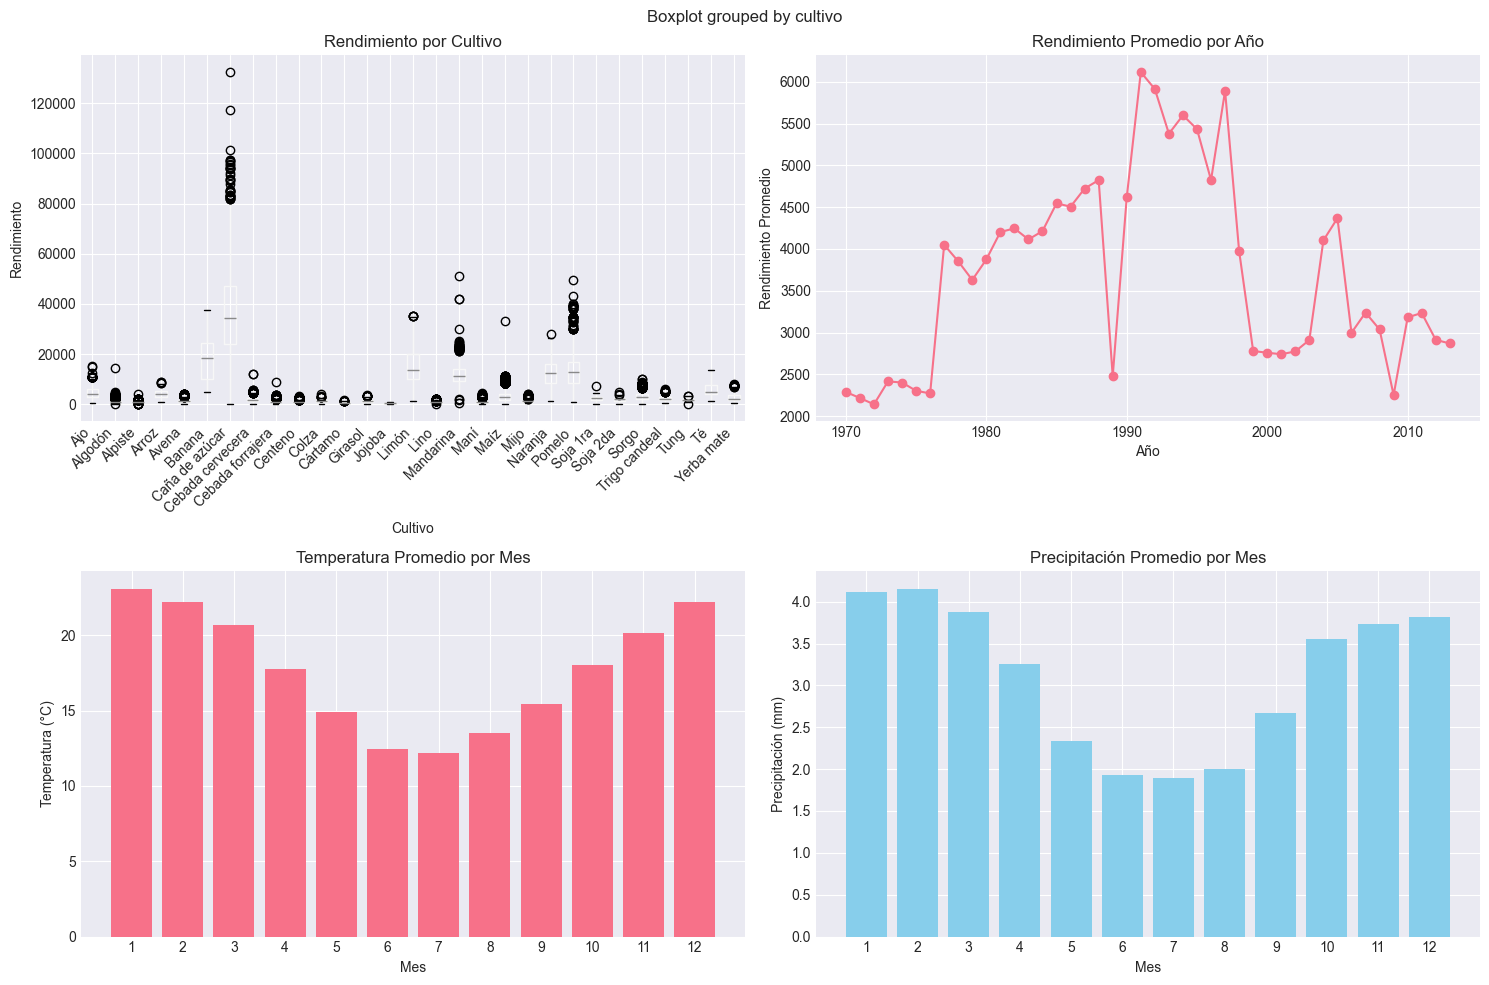

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df.boxplot(column='rendimiento', by='cultivo', ax=axes[0, 0])
axes[0, 0].set_title('Rendimiento por Cultivo')
axes[0, 0].set_xlabel('Cultivo')
axes[0, 0].set_ylabel('Rendimiento')
plt.sca(axes[0, 0])
plt.xticks(rotation=45, ha='right')

rendimiento_por_año = df.groupby('año')['rendimiento'].mean()
axes[0, 1].plot(rendimiento_por_año.index, rendimiento_por_año.values, marker='o')
axes[0, 1].set_title('Rendimiento Promedio por Año')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Rendimiento Promedio')
axes[0, 1].grid(True)

temp_cols = [f'temperatura_mes_{i}' for i in range(1, 13)]
temp_promedio_mensual = df[temp_cols].mean()
axes[1, 0].bar(range(1, 13), temp_promedio_mensual.values)
axes[1, 0].set_title('Temperatura Promedio por Mes')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Temperatura (°C)')
axes[1, 0].set_xticks(range(1, 13))

precip_cols = [f'precipitacion_mes_{i}' for i in range(1, 13)]
precip_promedio_mensual = df[precip_cols].mean()
axes[1, 1].bar(range(1, 13), precip_promedio_mensual.values, color='skyblue')
axes[1, 1].set_title('Precipitación Promedio por Mes')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Precipitación (mm)')
axes[1, 1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('../figures/eda_analisis_general.png', dpi=300, bbox_inches='tight')
plt.show()

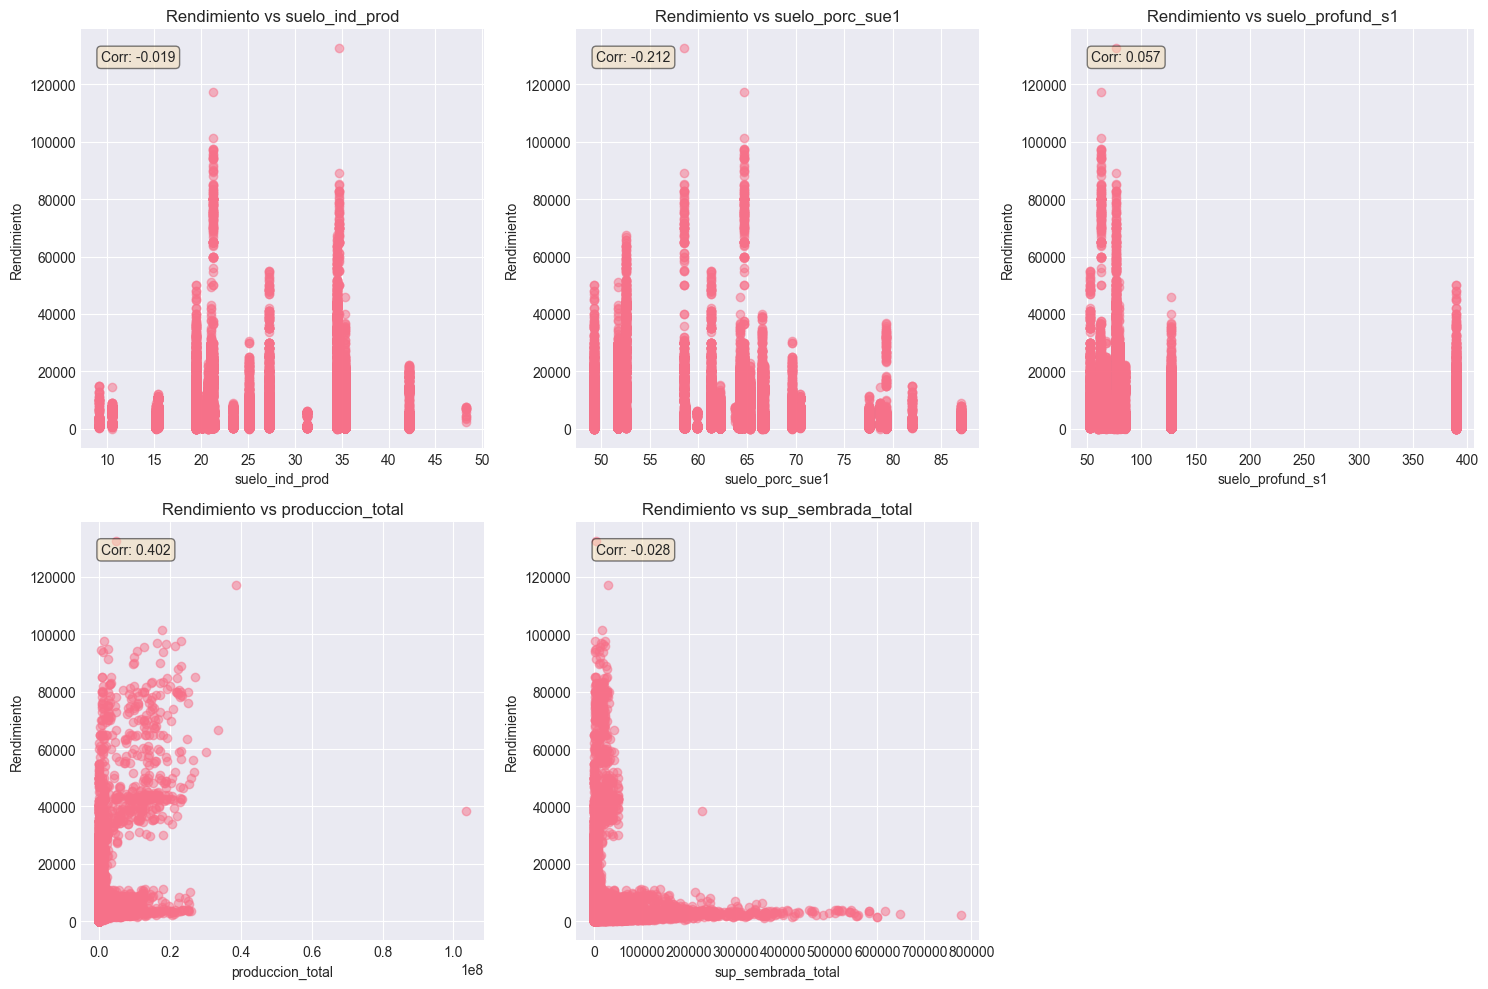

In [5]:
numeric_features = ['suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 
                    'produccion_total', 'sup_sembrada_total']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    axes[idx].scatter(df[feature], df['rendimiento'], alpha=0.5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Rendimiento')
    axes[idx].set_title(f'Rendimiento vs {feature}')
    
    corr = df[feature].corr(df['rendimiento'])
    axes[idx].text(0.05, 0.95, f'Corr: {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../figures/correlaciones_features.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Preparación de Features para Modelado

In [6]:
feature_cols = []

for i in range(1, 13):
    feature_cols.append(f'temperatura_mes_{i}')
    feature_cols.append(f'precipitacion_mes_{i}')

feature_cols.extend(['suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 
                     'suelo_alcalin_encoded', 'cultivo_encoded',
                     'produccion_total', 'sup_sembrada_total'])

print(f"Total de features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Total de features: 31
Features: ['temperatura_mes_1', 'precipitacion_mes_1', 'temperatura_mes_2', 'precipitacion_mes_2', 'temperatura_mes_3', 'precipitacion_mes_3', 'temperatura_mes_4', 'precipitacion_mes_4', 'temperatura_mes_5', 'precipitacion_mes_5', 'temperatura_mes_6', 'precipitacion_mes_6', 'temperatura_mes_7', 'precipitacion_mes_7', 'temperatura_mes_8', 'precipitacion_mes_8', 'temperatura_mes_9', 'precipitacion_mes_9', 'temperatura_mes_10', 'precipitacion_mes_10', 'temperatura_mes_11', 'precipitacion_mes_11', 'temperatura_mes_12', 'precipitacion_mes_12', 'suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 'suelo_alcalin_encoded', 'cultivo_encoded', 'produccion_total', 'sup_sembrada_total']


## 4. Split TRAIN/VAL/TEST

**Estrategia de división en 3 conjuntos:**

1. **DEV/TEST (ya realizado en Notebook 01):**
   - DEV: 1970-2013 (80%)
   - TEST: 2014-2025 (20%)

2. **TRAIN/VAL (dividimos DEV aquí):**
   - TRAIN: 80% de DEV (1970-2004) - para entrenar modelos
   - VAL: 20% de DEV (2005-2013) - para hyperparameter tuning
   - TEST: (2014-2025) - para evaluación final (UNA SOLA VEZ)

**Importante:** Esta división previene data leakage temporal y permite tuning de hiperparámetros sin contaminar el conjunto de test.

In [7]:
# Dividir DEV en TRAIN/VAL (80/20 cronológico)
df_dev_sorted = df_dev.sort_values('año').reset_index(drop=True)

años_dev = sorted(df_dev_sorted['año'].unique())
n_años_dev = len(años_dev)
split_año_idx_dev = int(n_años_dev * 0.8)
año_split_train_val = años_dev[split_año_idx_dev]

print(f"Total de años en DEV: {n_años_dev}")
print(f"Año de split TRAIN/VAL: {año_split_train_val}")
print(f"TRAIN: años {años_dev[0]} a {años_dev[split_año_idx_dev-1]}")
print(f"VAL: años {años_dev[split_año_idx_dev]} a {años_dev[-1]}")

# Crear máscaras para TRAIN y VAL
train_mask = df_dev_sorted['año'] < año_split_train_val
val_mask = df_dev_sorted['año'] >= año_split_train_val

df_train = df_dev_sorted[train_mask].copy()
df_val = df_dev_sorted[val_mask].copy()
df_test = df_test_full.sort_values('año').reset_index(drop=True)

# Extraer features y targets
X_train = df_train[feature_cols].values
y_train = df_train['rendimiento'].values
X_val = df_val[feature_cols].values
y_val = df_val['rendimiento'].values
X_test = df_test[feature_cols].values
y_test = df_test['rendimiento'].values

print(f"\nTamaño TRAIN: {X_train.shape} ({len(df_train)/len(df_dev_sorted)*100:.1f}% de DEV)")
print(f"Tamaño VAL: {X_val.shape} ({len(df_val)/len(df_dev_sorted)*100:.1f}% de DEV)")
print(f"Tamaño TEST: {X_test.shape}")
print(f"\nDistribución temporal:")
print(f"  TRAIN: {df_train['año'].min()}-{df_train['año'].max()}")
print(f"  VAL: {df_val['año'].min()}-{df_val['año'].max()}")
print(f"  TEST: {df_test['año'].min()}-{df_test['año'].max()}")

Total de años en DEV: 44
Año de split TRAIN/VAL: 2005
TRAIN: años 1970 a 2004
VAL: años 2005 a 2013

Tamaño TRAIN: (67229, 31) (81.6% de DEV)
Tamaño VAL: (15175, 31) (18.4% de DEV)
Tamaño TEST: (22203, 31)

Distribución temporal:
  TRAIN: 1970-2004
  VAL: 2005-2013
  TEST: 2014-2025


## 5. Normalización de Datos

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Media de X_train_scaled: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Std de X_train_scaled: {X_train_scaled.std(axis=0)[:5]}")
print(f"\nScaler ajustado SOLO en TRAIN, aplicado a VAL y TEST.")

Media de X_train_scaled: [ 2.29981257e-16  1.01462319e-16  1.67412827e-16 -4.05849277e-17
  6.89943771e-16]
Std de X_train_scaled: [1. 1. 1. 1. 1.]

Scaler ajustado SOLO en TRAIN, aplicado a VAL y TEST.


## 6. Aplicación de PCA

Vamos a aplicar PCA y analizar cuántos componentes necesitamos para explicar el 95% de la varianza

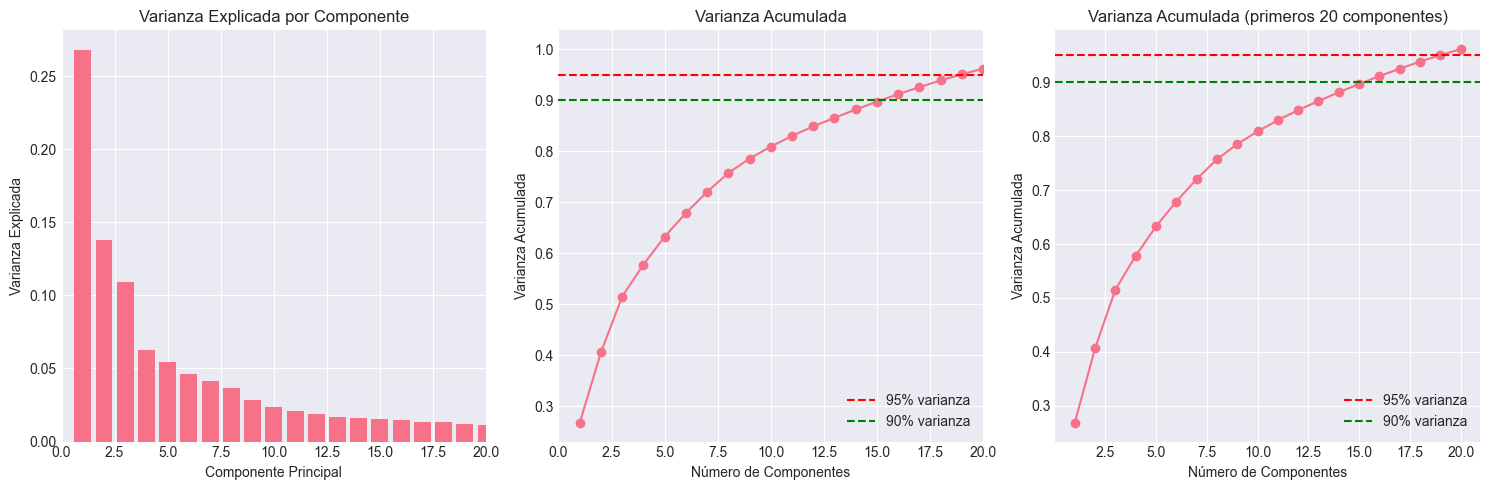

Componentes necesarios para 90% de varianza: 16
Componentes necesarios para 95% de varianza: 19
Varianza explicada por los primeros 2 componentes: 0.4061


In [9]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada)
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componente')
plt.xlim(0, min(20, len(varianza_explicada)))

plt.subplot(1, 3, 2)
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada')
plt.legend()
plt.grid(True)
plt.xlim(0, min(20, len(varianza_acumulada)))

plt.subplot(1, 3, 3)
plt.plot(range(1, min(20, len(varianza_acumulada)) + 1), 
         varianza_acumulada[:min(20, len(varianza_acumulada))], 
         marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada (primeros 20 componentes)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('../figures/pca_varianza_explicada.png', dpi=300, bbox_inches='tight')
plt.show()

n_components_95 = np.argmax(varianza_acumulada >= 0.95) + 1
n_components_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print(f"Componentes necesarios para 90% de varianza: {n_components_90}")
print(f"Componentes necesarios para 95% de varianza: {n_components_95}")
print(f"Varianza explicada por los primeros 2 componentes: {varianza_acumulada[1]:.4f}")

## 7. PCA en 2D - Visualización por Año y Rendimiento

Vamos a proyectar los datos en 2D y colorear por rendimiento para ver si se clusterizan

In [10]:
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)

print(f"Shape de X_train_pca_2d: {X_train_pca_2d.shape}")
print(f"Varianza explicada por 2 componentes: {pca_2d.explained_variance_ratio_.sum():.4f}")

Shape de X_train_pca_2d: (67229, 2)
Varianza explicada por 2 componentes: 0.4061


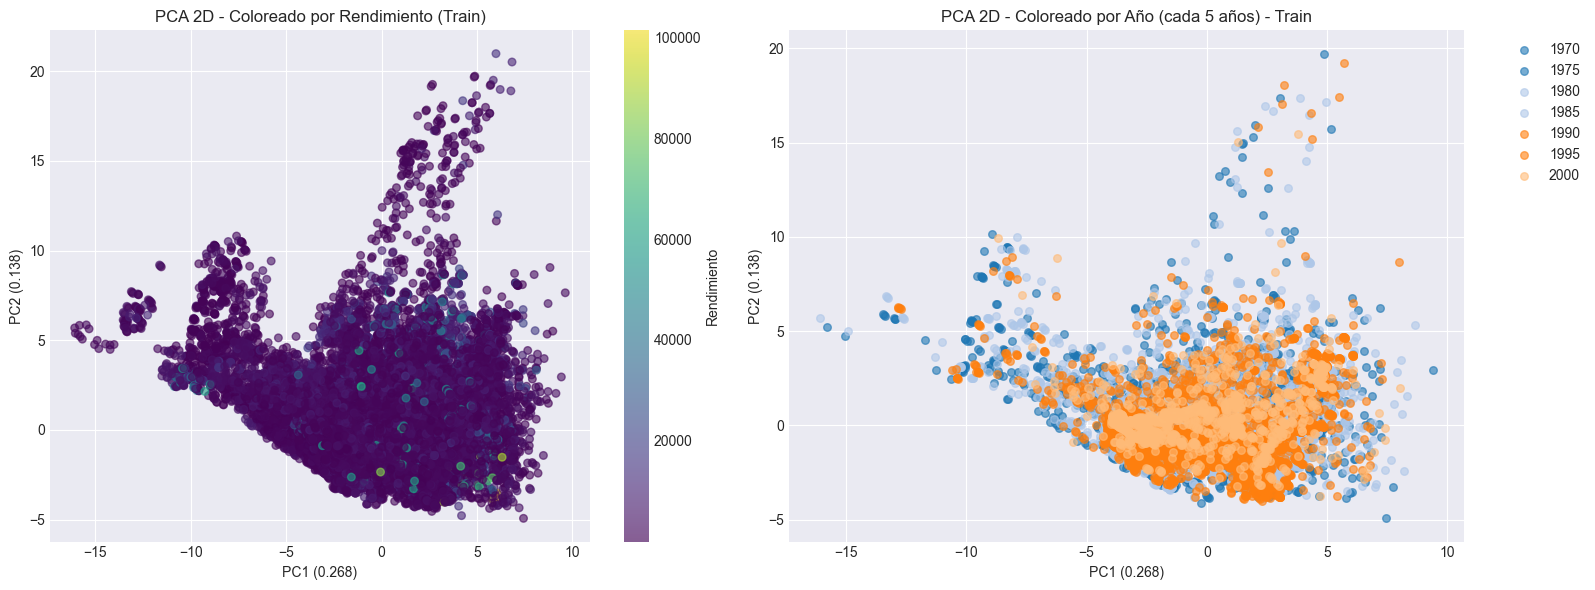

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], 
                           c=y_train, cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})')
axes[0].set_title('PCA 2D - Coloreado por Rendimiento (Train)')
plt.colorbar(scatter1, ax=axes[0], label='Rendimiento')

años_unicos_train = df_train['año'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(años_unicos_train)))

for idx, año in enumerate(sorted(años_unicos_train)[::5]):
    mask = df_train['año'] == año
    if mask.sum() > 0:
        pca_año = X_train_pca_2d[mask.values]
        axes[1].scatter(pca_año[:, 0], pca_año[:, 1], 
                       label=str(año), alpha=0.6, s=30, color=colors[idx])

axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})')
axes[1].set_title('PCA 2D - Coloreado por Año (cada 5 años) - Train')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/pca_2d_visualizacion.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. PCA con Número Óptimo de Componentes

Vamos a crear versiones de PCA con diferentes números de componentes para usar en los modelos

In [12]:
pca_optimal = PCA(n_components=n_components_95)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_val_pca = pca_optimal.transform(X_val_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

print(f"Shape de X_train con PCA (95% varianza): {X_train_pca.shape}")
print(f"Shape de X_val con PCA (95% varianza): {X_val_pca.shape}")
print(f"Shape de X_test con PCA (95% varianza): {X_test_pca.shape}")
print(f"Reducción de dimensionalidad: {X_train.shape[1]} -> {X_train_pca.shape[1]}")
print(f"\nPCA ajustado SOLO en TRAIN, aplicado a VAL y TEST.")

Shape de X_train con PCA (95% varianza): (67229, 19)
Shape de X_val con PCA (95% varianza): (15175, 19)
Shape de X_test con PCA (95% varianza): (22203, 19)
Reducción de dimensionalidad: 31 -> 19

PCA ajustado SOLO en TRAIN, aplicado a VAL y TEST.


## 9. Guardar Datos Preprocesados y Objetos

In [13]:
# Guardar datos sin escalar
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_val.npy', X_val)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_val.npy', y_val)
np.save('../data/processed/y_test.npy', y_test)

# Guardar datos escalados
np.save('../data/processed/X_train_scaled.npy', X_train_scaled)
np.save('../data/processed/X_val_scaled.npy', X_val_scaled)
np.save('../data/processed/X_test_scaled.npy', X_test_scaled)

# Guardar datos con PCA
np.save('../data/processed/X_train_pca.npy', X_train_pca)
np.save('../data/processed/X_val_pca.npy', X_val_pca)
np.save('../data/processed/X_test_pca.npy', X_test_pca)

print("Datos guardados exitosamente:")
print(f"  - 6 archivos base (X_train, X_val, X_test, y_train, y_val, y_test)")
print(f"  - 3 archivos escalados (X_train_scaled, X_val_scaled, X_test_scaled)")
print(f"  - 3 archivos PCA (X_train_pca, X_val_pca, X_test_pca)")
print(f"  Total: 12 archivos .npy")

Datos guardados exitosamente:
  - 6 archivos base (X_train, X_val, X_test, y_train, y_val, y_test)
  - 3 archivos escalados (X_train_scaled, X_val_scaled, X_test_scaled)
  - 3 archivos PCA (X_train_pca, X_val_pca, X_test_pca)
  Total: 12 archivos .npy


In [14]:
with open('../data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../data/processed/pca_optimal.pkl', 'wb') as f:
    pickle.dump(pca_optimal, f)

with open('../data/processed/pca_2d.pkl', 'wb') as f:
    pickle.dump(pca_2d, f)

with open('../data/processed/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("Objetos de preprocesamiento guardados.")

Objetos de preprocesamiento guardados.


## 10. Análisis de Componentes Principales

In [15]:
componentes = pd.DataFrame(
    pca_optimal.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_optimal.n_components_)],
    index=feature_cols
)

print("Features más importantes para los primeros 3 componentes principales:\n")

for i in range(min(3, pca_optimal.n_components_)):
    pc_name = f'PC{i+1}'
    top_features = componentes[pc_name].abs().nlargest(5)
    print(f"\n{pc_name}:")
    for feature, value in top_features.items():
        print(f"  {feature}: {componentes.loc[feature, pc_name]:.4f}")

Features más importantes para los primeros 3 componentes principales:


PC1:
  temperatura_mes_4: 0.2784
  temperatura_mes_9: 0.2770
  temperatura_mes_10: 0.2749
  temperatura_mes_8: 0.2749
  temperatura_mes_5: 0.2682

PC2:
  precipitacion_mes_7: 0.3236
  precipitacion_mes_6: 0.3154
  precipitacion_mes_8: 0.3138
  temperatura_mes_12: -0.2925
  temperatura_mes_1: -0.2884

PC3:
  temperatura_mes_7: 0.3100
  precipitacion_mes_1: -0.3097
  temperatura_mes_6: 0.3087
  precipitacion_mes_2: -0.2897
  precipitacion_mes_12: -0.2876
